In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import seaborn as sns 

In [2]:
import numpy as np
from tailnflows.utils import load_raw_data, load_experiment_output_data


# Load experiment results
experiment_output = load_experiment_output_data('sp500/2026-08-26-de-sp500-try01')
# for k, v in experiment_output.items():
#     print(f"{k}: {v}")

# Put experiment results in dataframe
rows = []
for model, run_datas in experiment_output.items():
    for rd in run_datas:
        rows.append({
            'data': model.split('-')[0],
            **rd
        })

df = pd.DataFrame(rows)
print(df)

     data    model  dim  seed  split      tst_ll      val_ll  \
0   sp500  ttf_fix  140     0      0  134.912354  136.424683   
1   sp500  ttf_fix  140    17      1  135.457108  135.301300   
2   sp500  ttf_fix  140    34      2  132.041489  134.823807   
3   sp500  ttf_mod  140    17      1  134.384506  134.220551   
4   sp500  ttf_mod  140     0      0  133.733246  135.297150   
5   sp500  ttf_fix  140    51      3  135.892044  137.057098   
6   sp500  ttf_mod  140    34      2  131.078079  133.870804   
7   sp500  ttf_fix  140    68      4  137.335159  139.282608   
8   sp500  ttf_mod  140    51      3  134.490875  135.739548   
9   sp500  ttf_mod  140    68      4  136.067764  138.160568   
10  sp500  ttf_fix  140    85      5  138.132111  138.010361   
11  sp500  ttf_fix  140   102      6  137.766357  134.436768   
12  sp500  ttf_fix  140   119      7  134.554352  133.927612   
13  sp500  ttf_mod  140    85      5  136.863129  136.687469   
14  sp500  ttf_mod  140   102      6  13

In [27]:
grouper = ['model', 'depth']

# select only experiments with specific parameters
selector = np.ones(len(df), dtype=bool)
# selector &= df['batch_size'] == 100
# selector &= df['tail_bound'] == 2.5
# selector = np.logical_and(
#     df['batch_size'] == 100,
#     df['tail_bound'] == 2.5
# )
df = df[selector]

# aggregate nll results over splits
grouped = df.groupby(grouper)
agg = grouped[['val_ll', 'tst_ll']].agg(['mean', 'sem', 'std'])
print(agg)

# Select best test nll results and its std
best = agg['tst_ll'].sort_values(by='mean')
within = best.iloc[0]['mean'] + best.iloc[0]['std']

def highlight_by_mean(row, threshold=7):
    """
    Highlight the row if the 'Mean' value is below the given threshold.
    """
    if row['mean'] < threshold:
        # Highlight entire row in a light green
        return ['background-color: #dfffdf'] * len(row) # light-green
    else:
        # No highlight
        return ['background-color: white'] * len(row)

# Show sorted results
best.style.apply(
    highlight_by_mean, 
    axis=1, 
    threshold=within
)

                   val_ll                          tst_ll                    
                     mean       sem       std        mean       sem       std
model   depth                                                                
ttf_fix 1      135.992564  0.612935  1.938270  136.030505  0.843586  2.667653
ttf_mod 1      134.834039  0.607923  1.922422  134.819745  0.837308  2.647802


,,mean,sem,std
model,depth,,,
ttf_mod,1,134.819745,0.837308,2.647802
ttf_fix,1,136.030505,0.843586,2.667653


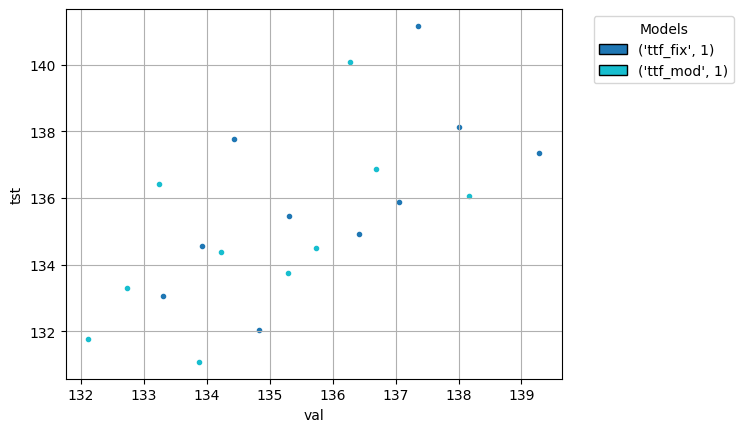

In [28]:
# Plot final test nll against final validation nll for all models (lower test nll is better)!
from matplotlib.patches import Patch

color_palette = plt.get_cmap('tab10', len(agg.index))  # Using a colormap

model_to_color = {model: color_palette(i) for i, model in enumerate(agg.index)}

selected_ix = []
for ix, group in grouped:
    plt.scatter(group.val_ll, group.tst_ll, color=model_to_color[ix], marker='.')
    # plt.scatter(ix[-2], group.tst_ll, c=model_to_color[ix])
    ix = (ix[0], int(ix[1]))
    selected_ix.append(ix)

plt.ylabel('tst')
plt.xlabel('val')
legend_elements = [Patch(facecolor=model_to_color[model], edgecolor='black', label=model) 
                   for model in selected_ix] # integer in the models legend represents depth parameter
plt.legend(handles=legend_elements, title="Models", loc='upper left', bbox_to_anchor=(1.05, 1))
plt.grid()
plt.show()

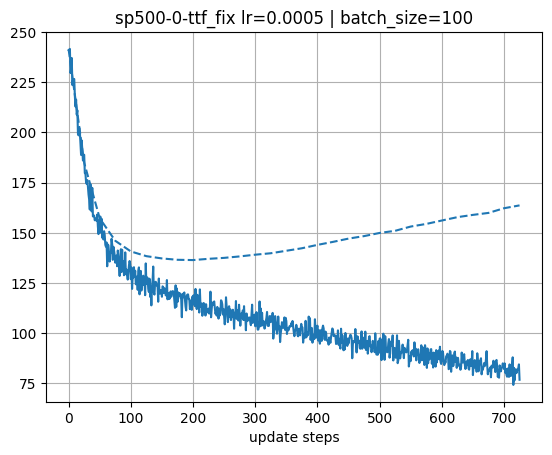

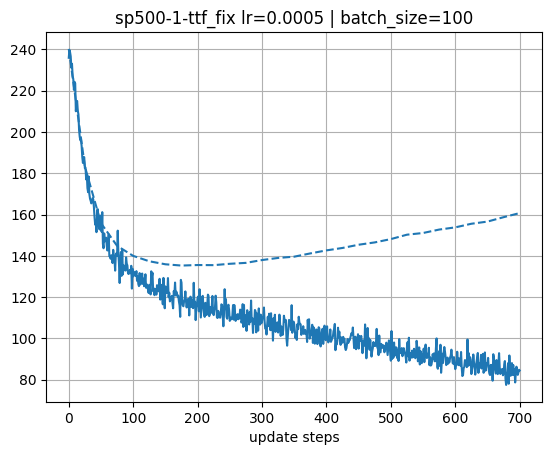

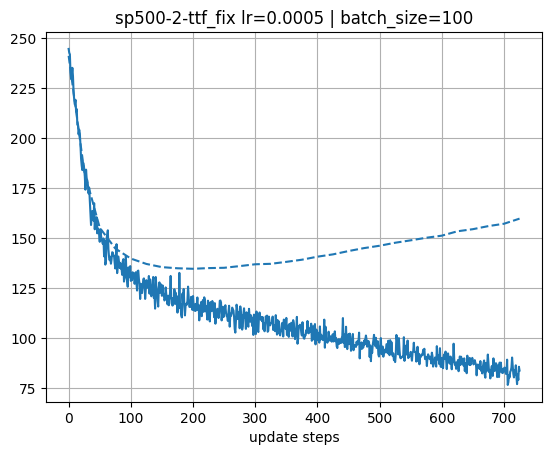

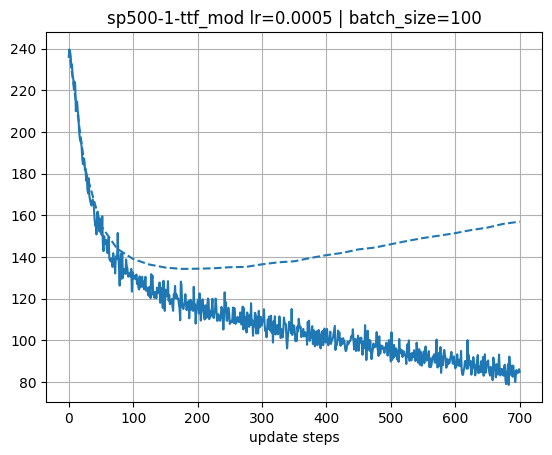

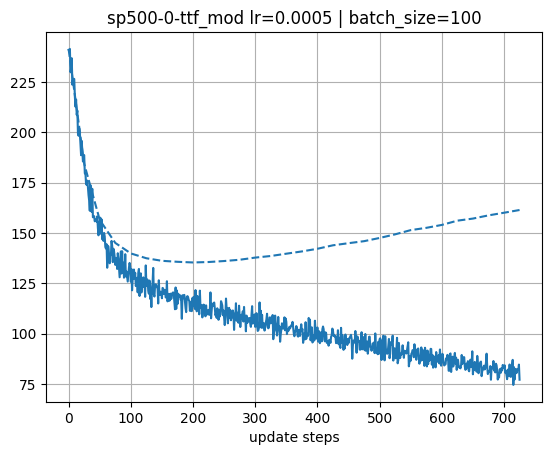

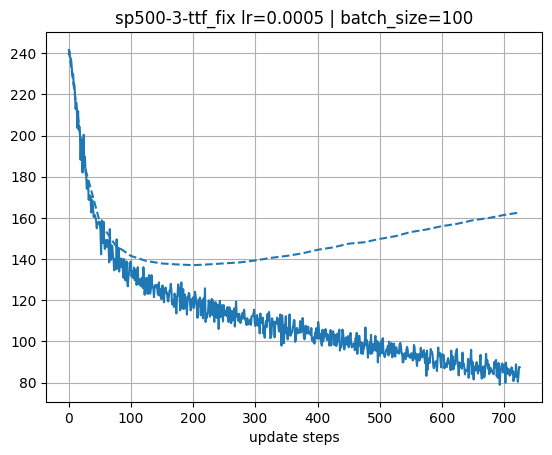

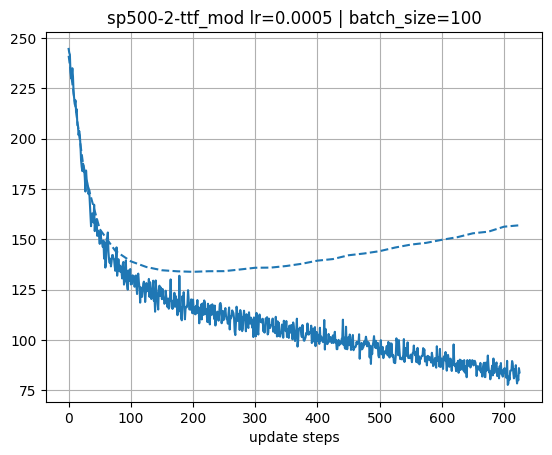

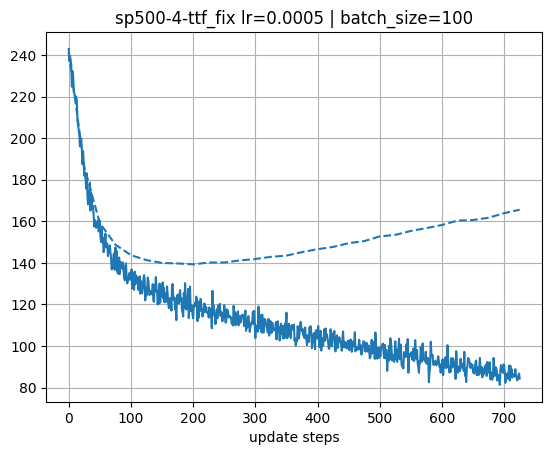

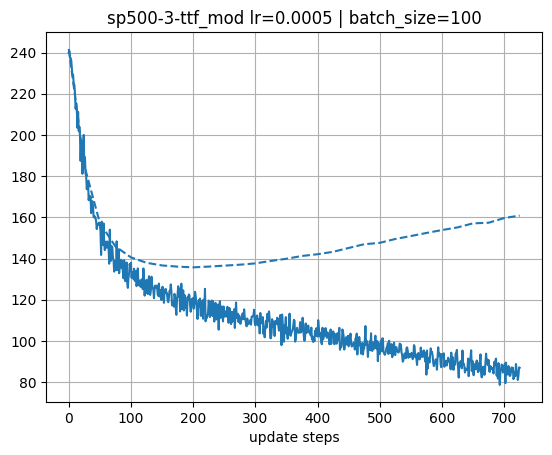

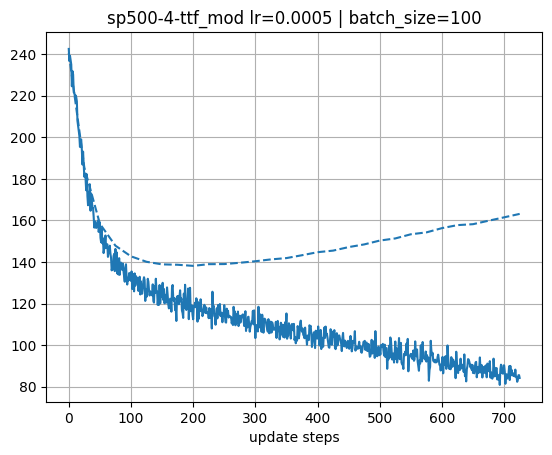

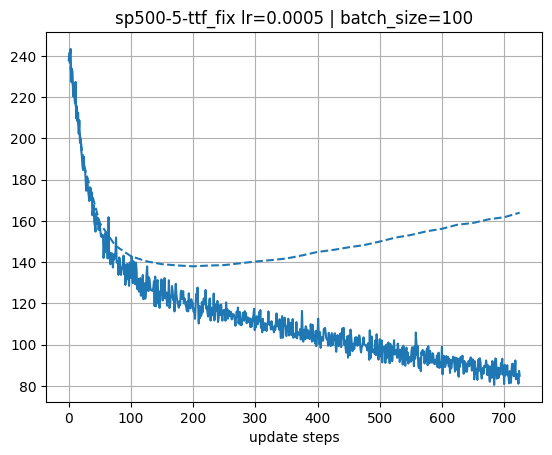

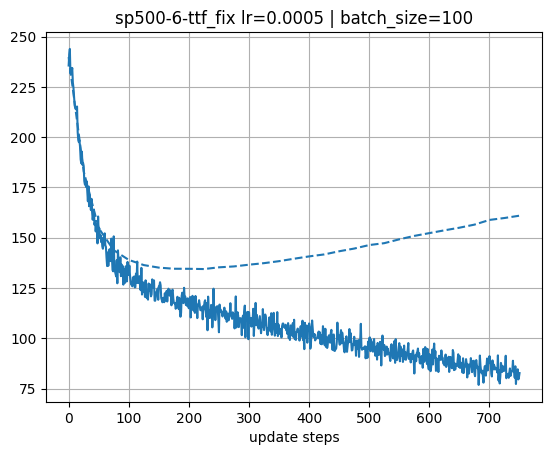

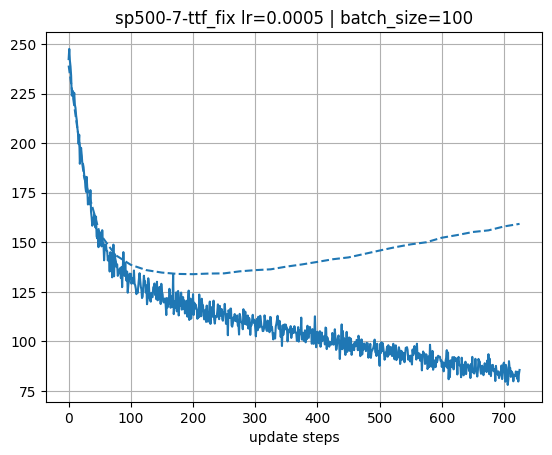

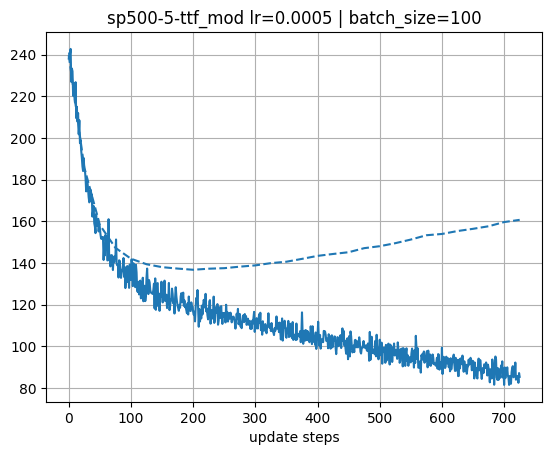

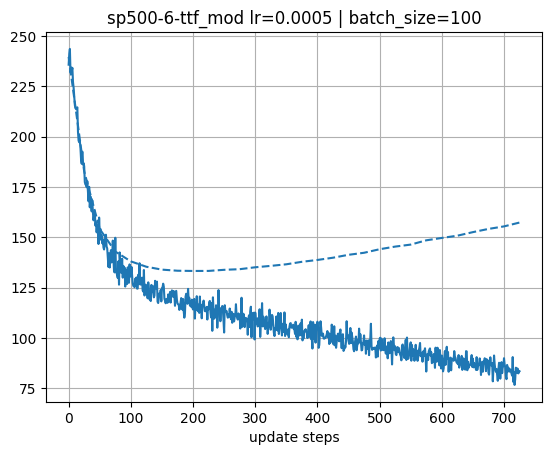

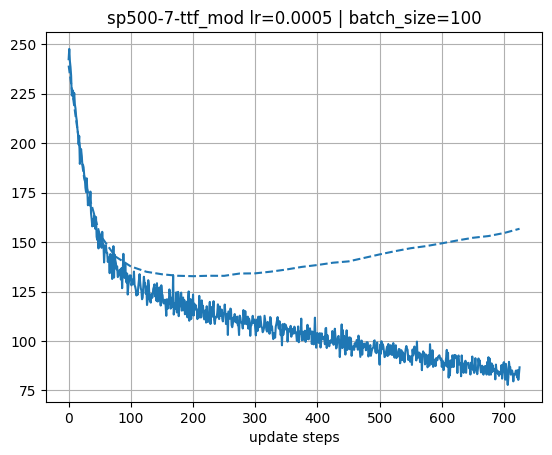

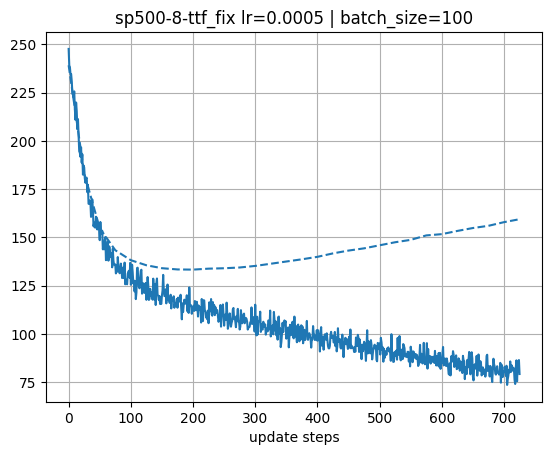

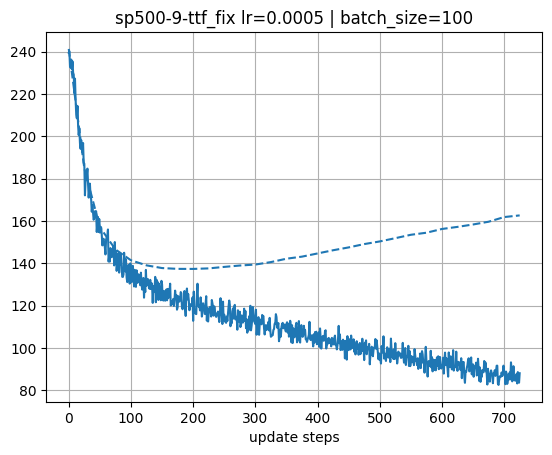

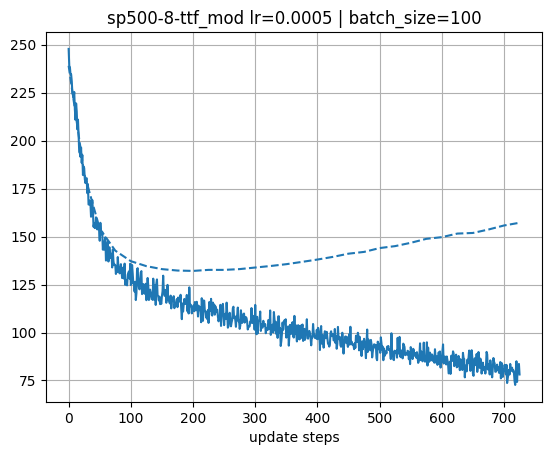

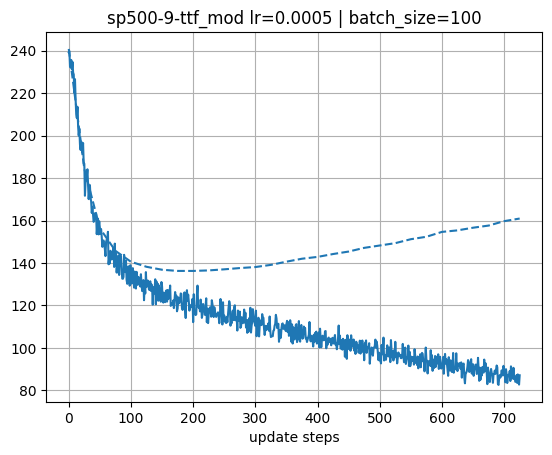

In [29]:
# print evolution of train and val loss for all models
for label, runs in experiment_output.items():
    for run in runs:
        losses = load_raw_data(run['loss_path'])[label][
            run['loss_ix']
        ]

        plt.title(f'{label} lr={run["lr"]} | batch_size={run["batch_size"]}')
        l, = plt.plot(np.arange(len(losses['losses'])), losses['losses'], label='') # training losses
        plt.plot(losses['steps'], losses['vlosses'], linestyle='--', c=l.get_color()) # validation losses
        plt.xlabel('update steps')
    plt.grid()
    plt.show()

In [31]:
from pathlib import Path
from tailnflows.utils import get_data_path

# Load split data
data_source = "sp500"
split = 1
tail_path = f'{get_data_path()}/splits/{data_source}/{split}'
if not Path(f"{tail_path}.p").is_file():
    raise Exception(
        f"Split data not present at {tail_path}.p, either configure "
        "TAILNFLOWS_DATA_DIR, or run `python experiments/density_estimation_real_data/generate_splits.py`"
    )
 
splits_and_tail = load_raw_data(tail_path)["experiment_data"][0]
# print(splits_and_tail)

In [36]:
# Add test NLL/dim as column
df['test_neg_ll_per_dim'] = df['tst_ll'] / df['dim']
df.head()

,data,model,dim,seed,split,tst_ll,val_ll,tst_ix,loss_path,loss_ix,...,num_steps,batch_size,early_stop_patience,eval_period,lr_scheduler,depth,num_bins,tail_bound,test_neg_ll_per_dim,readable_name
0,sp500,ttf_fix,140,0,0,134.912354,136.424683,"tensor(200, dtype=torch.int32)",/home/vonbalnd/MApaper/tailnflows/experiment_o...,0,...,2000,100,500,25,None,1,5,2.5,0.963660,TTF (fix)
1,sp500,ttf_fix,140,17,1,135.457108,135.301300,"tensor(175, dtype=torch.int32)",/home/vonbalnd/MApaper/tailnflows/experiment_o...,0,...,2000,100,500,25,None,1,5,2.5,0.967551,TTF (fix)
2,sp500,ttf_fix,140,34,2,132.041489,134.823807,"tensor(200, dtype=torch.int32)",/home/vonbalnd/MApaper/tailnflows/experiment_o...,0,...,2000,100,500,25,None,1,5,2.5,0.943153,TTF (fix)
3,sp500,ttf_mod,140,17,1,134.384506,134.220551,"tensor(175, dtype=torch.int32)",/home/vonbalnd/MApaper/tailnflows/experiment_o...,0,...,2000,100,500,25,None,1,5,2.5,0.959889,TTF (mod)
4,sp500,ttf_mod,140,0,0,133.733246,135.297150,"tensor(200, dtype=torch.int32)",/home/vonbalnd/MApaper/tailnflows/experiment_o...,0,...,2000,100,500,25,None,1,5,2.5,0.955237,TTF (mod)


In [59]:
# Add a readable_name column
name_map = {
    # 'ttf': 'TTF',
    'ttf_fix': 'TTF (fix)',
    'ttf_mod': 'TTF (mod)',
    # 'mtaf': 'mTAF',
    # 'gtaf': 'gTAF',
}
df['readable_name'] = df['model'].apply(lambda x: name_map.get(x, x))

# # Count non-NA cells for each column
df.groupby('readable_name').count()

,data,model,dim,seed,split,tst_ll,val_ll,tst_ix,loss_path,loss_ix,lr,num_steps,batch_size,early_stop_patience,eval_period,lr_scheduler,depth,num_bins,tail_bound,test_neg_ll_per_dim
readable_name,,,,,,,,,,,,,,,,,,,,
TTF (fix),10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,0,10,10,10,10
TTF (mod),10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,0,10,10,10,10


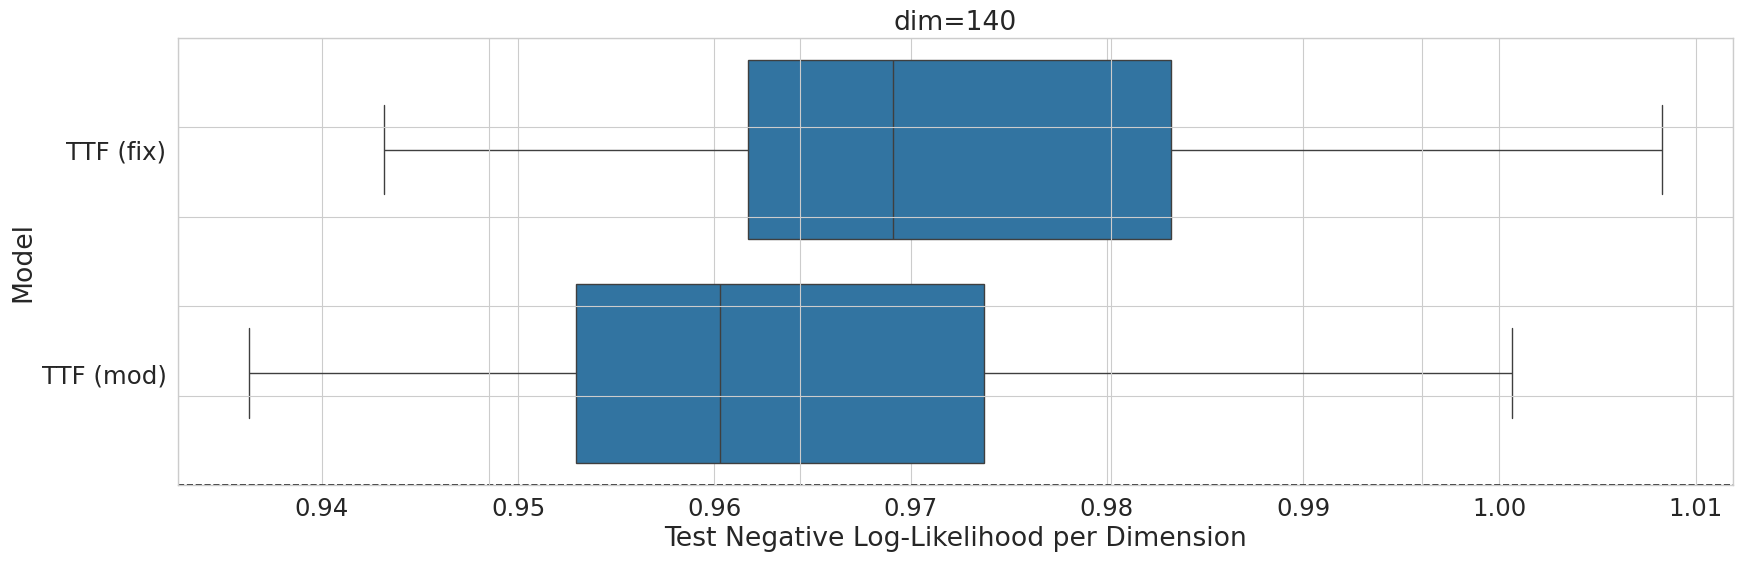

In [60]:
# Plot test nll per dimension for experiment data of specified dimensionality

target_dims = [140] # our sp500 is 140-dimensional
fig, axarr = plt.subplots(1, len(target_dims), figsize=(18, 6), tight_layout=True, sharey=True)
if len(target_dims) == 1:
  axarr = [axarr]

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=2.)

for i, dim in enumerate(target_dims):
  j = 1

  wanted_data = df[df['dim'] == dim]

  sns.boxplot(
      data=wanted_data,
      x='test_neg_ll_per_dim',
      y='readable_name',
      order=name_map.values(),
      orient='h',
      ax=axarr[i],
  )

  axarr[i].axhline(1.5, linestyle='--', c='black')
  axarr[i].set_title(f'dim={dim}')
  axarr[i].set_xlabel('')
  axarr[i].set_ylabel('Model')

  fig.add_subplot(111, frameon=False)
  plt.xlabel('Test Negative Log-Likelihood per Dimension')
  plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
  plt.tight_layout()
  # plt.savefig(f"./real_sp500.png")